In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\hp\Downloads\DataSetX.csv")

df.head()

,conversation_id_str,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,category
0,1.528370e+18,Sun May 22 13:33:33 +0000 2022,1083,1. Artificial intelligence [AI] - software alg...,1.528370e+18,https://pbs.twimg.com/media/FTXbBPEVEAAkOYX.jpg,mishadavinci,en,NaN,14,137,219,https://x.com/undefined/status/152836846773207...,1.075480e+18,AI_Technology
1,1.965810e+18,Wed Sep 10 16:00:57 +0000 2025,596,⭐️ Beyond Automation: How AI Supports Industry...,1.965810e+18,https://pbs.twimg.com/media/G0fzsobaIAAJkGy.jpg,NaN,en,NaN,49,21,400,https://x.com/undefined/status/196580771859519...,1.425830e+18,AI_Technology
2,1.897720e+18,Thu Mar 06 18:28:17 +0000 2025,1937,Introducing an advanced Articulate Medical Int...,1.897720e+18,https://pbs.twimg.com/ext_tw_video_thumb/18977...,NaN,en,NaN,65,134,444,https://x.com/undefined/status/189771587693128...,3.383820e+07,AI_Technology
3,1.596890e+18,Sun Nov 27 15:43:22 +0000 2022,554,ARTIFICIAL INTELLIGENCE - computer systems tha...,1.596890e+18,https://pbs.twimg.com/media/FilNNusUoAE9mrM.png,mishadavinci,en,NaN,10,69,128,https://x.com/undefined/status/159689244581542...,1.075480e+18,AI_Technology
4,1.965250e+18,Tue Sep 09 03:19:00 +0000 2025,3186,Google presents an AI system to write expert-l...,1.965250e+18,https://pbs.twimg.com/media/G0X5MFva4AA3inC.jpg,NaN,en,NaN,76,62,558,https://x.com/undefined/status/196525357722158...,7.944330e+17,AI_Technology


In [2]:
df.shape

(1349, 15)

In [3]:
df.isnull().sum()

conversation_id_str           0
created_at                    0
favorite_count                0
full_text                     0
id_str                        0
image_url                   207
in_reply_to_screen_name    1313
lang                          0
location                   1349
quote_count                   0
reply_count                   0
retweet_count                 0
tweet_url                     0
user_id_str                   0
category                      0
dtype: int64

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1349 entries, 0 to 1348
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   conversation_id_str      1349 non-null   float64
 1   created_at               1349 non-null   str    
 2   favorite_count           1349 non-null   int64  
 3   full_text                1349 non-null   str    
 4   id_str                   1349 non-null   float64
 5   image_url                1142 non-null   str    
 6   in_reply_to_screen_name  36 non-null     str    
 7   lang                     1349 non-null   str    
 8   location                 0 non-null      float64
 9   quote_count              1349 non-null   int64  
 10  reply_count              1349 non-null   int64  
 11  retweet_count            1349 non-null   int64  
 12  tweet_url                1349 non-null   str    
 13  user_id_str              1349 non-null   float64
 14  category                 1349 non-n

In [5]:
df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce")

df["created_at"].head()

C:\Users\hp\AppData\Local\Temp\ipykernel_10180\1404653592.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce")


0   2022-05-22 13:33:33+00:00
1   2025-09-10 16:00:57+00:00
2   2025-03-06 18:28:17+00:00
3   2022-11-27 15:43:22+00:00
4   2025-09-09 03:19:00+00:00
Name: created_at, dtype: datetime64[us, UTC]

In [6]:
df["year"] = df["created_at"].dt.year
df["month"] = df["created_at"].dt.month
df["day_of_week"] = df["created_at"].dt.day_name()

df[["created_at", "year", "month", "day_of_week"]].head()

,created_at,year,month,day_of_week
0,2022-05-22 13:33:33+00:00,2022,5,Sunday
1,2025-09-10 16:00:57+00:00,2025,9,Wednesday
2,2025-03-06 18:28:17+00:00,2025,3,Thursday
3,2022-11-27 15:43:22+00:00,2022,11,Sunday
4,2025-09-09 03:19:00+00:00,2025,9,Tuesday


In [7]:
df["total_engagement"] = (
    df["favorite_count"]
    + df["retweet_count"]
    + df["reply_count"]
    + df["quote_count"]
)

df[[
    "favorite_count",
    "retweet_count",
    "reply_count",
    "quote_count",
    "total_engagement"
]].head()

,favorite_count,retweet_count,reply_count,quote_count,total_engagement
0,1083,219,137,14,1453
1,596,400,21,49,1066
2,1937,444,134,65,2580
3,554,128,69,10,761
4,3186,558,62,76,3882


In [8]:
top_10 = df.sort_values(
    "total_engagement",
    ascending=False
)[[
    "created_at",
    "full_text",
    "favorite_count",
    "retweet_count",
    "reply_count",
    "quote_count",
    "total_engagement"
]].head(10)

top_10

,created_at,full_text,favorite_count,retweet_count,reply_count,quote_count,total_engagement
301,2024-04-24 08:42:08+00:00,This graph illustrates the woke mind virus tak...,310251,58723,19411,3832,392217
339,2024-11-25 16:15:36+00:00,We either fix the woke mind virus infection in...,316941,47872,13922,2194,380929
300,2024-05-19 21:42:35+00:00,Bringing connectivity to remote communities ra...,254615,25313,18139,2954,301021
387,2024-12-05 15:22:22+00:00,This is a big part of the reason your children...,190735,40462,13307,1992,246496
335,2025-09-15 17:07:47+00:00,colleges tend to be less conservative because ...,182743,13859,1906,498,199006
808,2024-11-26 19:54:42+00:00,Cue music from the movie,162451,12814,7003,619,182887
678,2023-01-17 17:52:24+00:00,The party is on!! ️ https://t.co/zoa3qmcXqC,134210,12854,8589,1349,157002
521,2025-08-29 15:33:12+00:00,In order to survive an ideology that fails to ...,122620,24659,7344,1249,155872
597,2024-10-14 07:36:26+00:00,Sex Education s Connor Swindells had his wedd...,132916,6786,506,1587,141795
771,2025-05-30 20:00:09+00:00,France is banning smoking cigarettes in all pu...,122059,4933,1269,3958,132219


Matplotlib is building the font cache; this may take a moment.


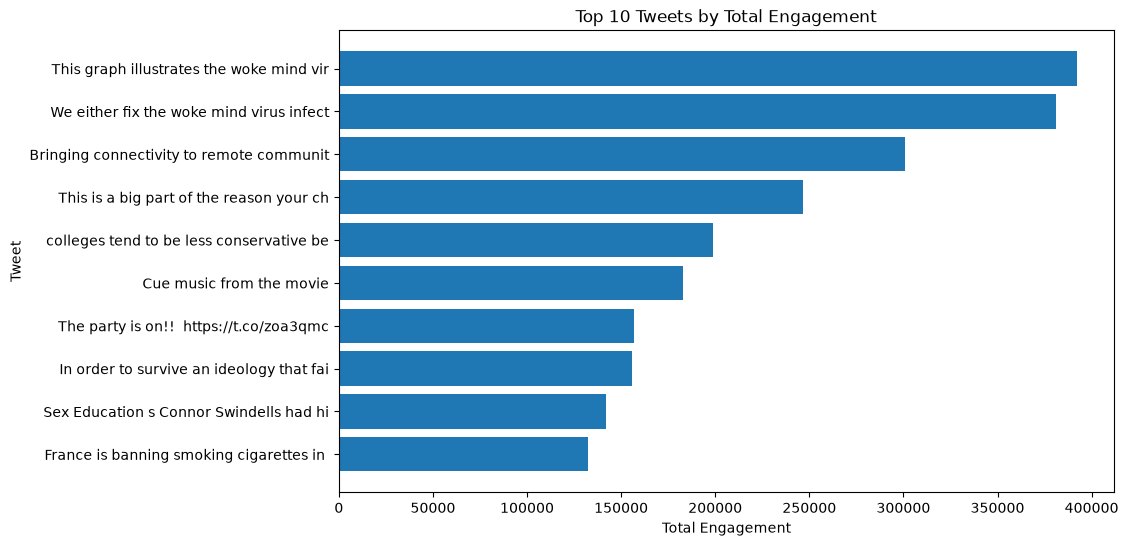

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    top_10["full_text"].str[:40],
    top_10["total_engagement"]
)

plt.xlabel("Total Engagement")
plt.ylabel("Tweet")
plt.title("Top 10 Tweets by Total Engagement")
plt.gca().invert_yaxis()

plt.show()

In [10]:
category_engagement = (
    df.groupby("category")["total_engagement"]
      .agg(["count", "sum", "mean"])
      .sort_values("sum", ascending=False)
)

category_engagement

,count,sum,mean
category,,,
Education,317,3827473,12074.047319
Sports,194,1659504,8554.144330
Health,146,511746,3505.109589
Music_Movie,287,435759,1518.324042
AI_Technology,295,241353,818.145763
Finance,110,37518,341.072727


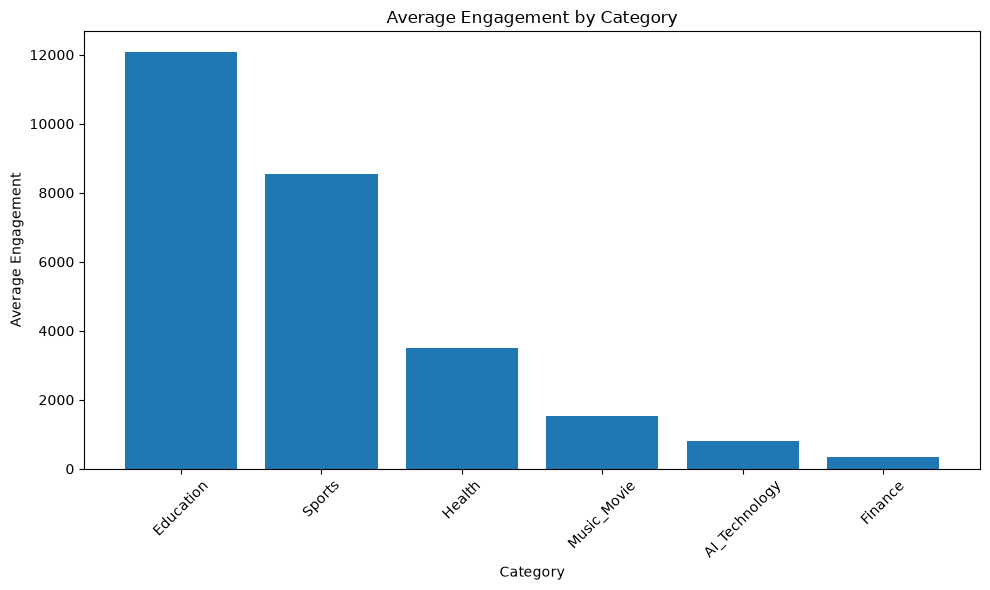

In [11]:
plt.figure(figsize=(10, 6))

plt.bar(
    category_engagement.index.astype(str),
    category_engagement["mean"]
)

plt.xlabel("Category")
plt.ylabel("Average Engagement")
plt.title("Average Engagement by Category")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [12]:
tweets_by_year = df.groupby("year").size()

tweets_by_year

year
2016       6
2017       9
2018       5
2019       4
2020       6
2021      11
2022      10
2023      18
2024      54
2025    1226
dtype: int64

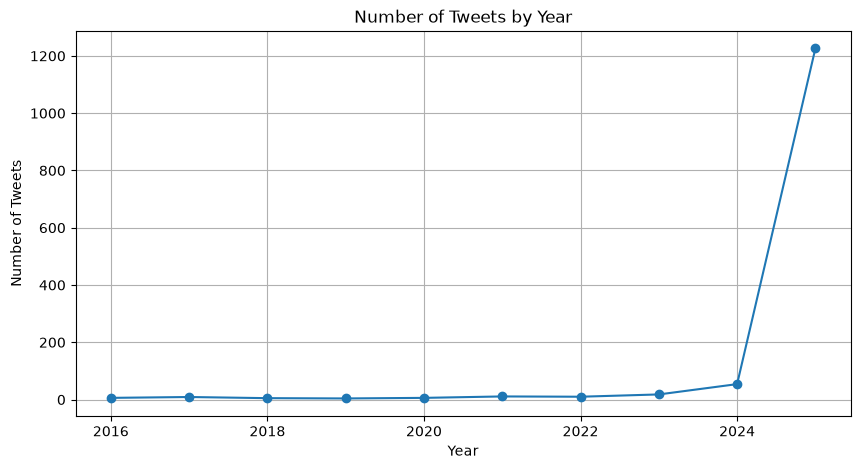

In [13]:
plt.figure(figsize=(10, 5))

plt.plot(
    tweets_by_year.index,
    tweets_by_year.values,
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Number of Tweets")
plt.title("Number of Tweets by Year")
plt.grid(True)

plt.show()

In [14]:
#Twitter Data Analysis

In [15]:
##1.Project Overview

This project analyzes Twitter data to undestand engagement patterns, content, categories, and activity over time using Python 

##.2 Import Libraries

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##3. Load Dataset

In [18]:
df = pd.read_csv(r"C:\Users\hp\Downloads\DataSetX.csv")
df.head()

,conversation_id_str,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,category
0,1.528370e+18,Sun May 22 13:33:33 +0000 2022,1083,1. Artificial intelligence [AI] - software alg...,1.528370e+18,https://pbs.twimg.com/media/FTXbBPEVEAAkOYX.jpg,mishadavinci,en,NaN,14,137,219,https://x.com/undefined/status/152836846773207...,1.075480e+18,AI_Technology
1,1.965810e+18,Wed Sep 10 16:00:57 +0000 2025,596,⭐️ Beyond Automation: How AI Supports Industry...,1.965810e+18,https://pbs.twimg.com/media/G0fzsobaIAAJkGy.jpg,NaN,en,NaN,49,21,400,https://x.com/undefined/status/196580771859519...,1.425830e+18,AI_Technology
2,1.897720e+18,Thu Mar 06 18:28:17 +0000 2025,1937,Introducing an advanced Articulate Medical Int...,1.897720e+18,https://pbs.twimg.com/ext_tw_video_thumb/18977...,NaN,en,NaN,65,134,444,https://x.com/undefined/status/189771587693128...,3.383820e+07,AI_Technology
3,1.596890e+18,Sun Nov 27 15:43:22 +0000 2022,554,ARTIFICIAL INTELLIGENCE - computer systems tha...,1.596890e+18,https://pbs.twimg.com/media/FilNNusUoAE9mrM.png,mishadavinci,en,NaN,10,69,128,https://x.com/undefined/status/159689244581542...,1.075480e+18,AI_Technology
4,1.965250e+18,Tue Sep 09 03:19:00 +0000 2025,3186,Google presents an AI system to write expert-l...,1.965250e+18,https://pbs.twimg.com/media/G0X5MFva4AA3inC.jpg,NaN,en,NaN,76,62,558,https://x.com/undefined/status/196525357722158...,7.944330e+17,AI_Technology


##4. Data Quality Check

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1349 entries, 0 to 1348
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   conversation_id_str      1349 non-null   float64
 1   created_at               1349 non-null   str    
 2   favorite_count           1349 non-null   int64  
 3   full_text                1349 non-null   str    
 4   id_str                   1349 non-null   float64
 5   image_url                1142 non-null   str    
 6   in_reply_to_screen_name  36 non-null     str    
 7   lang                     1349 non-null   str    
 8   location                 0 non-null      float64
 9   quote_count              1349 non-null   int64  
 10  reply_count              1349 non-null   int64  
 11  retweet_count            1349 non-null   int64  
 12  tweet_url                1349 non-null   str    
 13  user_id_str              1349 non-null   float64
 14  category                 1349 non-n

##5. Data Cleaning

In [21]:
df["created_at"] = pd.to_datetime(
    df["created_at"],
    format="mixed",
    errors="coerce"
)

df["year"] = df["created_at"].dt.year
df["month"] = df["created_at"].dt.month
df["day_of_week"] = df["created_at"].dt.day_name()

df["total_engagement"] = (
    df["favorite_count"]
    + df["retweet_count"]
    + df["reply_count"]
    + df["quote_count"]
)

df.head()

,conversation_id_str,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,category,year,month,day_of_week,total_engagement
0,1.528370e+18,2022-05-22 13:33:33+00:00,1083,1. Artificial intelligence [AI] - software alg...,1.528370e+18,https://pbs.twimg.com/media/FTXbBPEVEAAkOYX.jpg,mishadavinci,en,NaN,14,137,219,https://x.com/undefined/status/152836846773207...,1.075480e+18,AI_Technology,2022,5,Sunday,1453
1,1.965810e+18,2025-09-10 16:00:57+00:00,596,⭐️ Beyond Automation: How AI Supports Industry...,1.965810e+18,https://pbs.twimg.com/media/G0fzsobaIAAJkGy.jpg,NaN,en,NaN,49,21,400,https://x.com/undefined/status/196580771859519...,1.425830e+18,AI_Technology,2025,9,Wednesday,1066
2,1.897720e+18,2025-03-06 18:28:17+00:00,1937,Introducing an advanced Articulate Medical Int...,1.897720e+18,https://pbs.twimg.com/ext_tw_video_thumb/18977...,NaN,en,NaN,65,134,444,https://x.com/undefined/status/189771587693128...,3.383820e+07,AI_Technology,2025,3,Thursday,2580
3,1.596890e+18,2022-11-27 15:43:22+00:00,554,ARTIFICIAL INTELLIGENCE - computer systems tha...,1.596890e+18,https://pbs.twimg.com/media/FilNNusUoAE9mrM.png,mishadavinci,en,NaN,10,69,128,https://x.com/undefined/status/159689244581542...,1.075480e+18,AI_Technology,2022,11,Sunday,761
4,1.965250e+18,2025-09-09 03:19:00+00:00,3186,Google presents an AI system to write expert-l...,1.965250e+18,https://pbs.twimg.com/media/G0X5MFva4AA3inC.jpg,NaN,en,NaN,76,62,558,https://x.com/undefined/status/196525357722158...,7.944330e+17,AI_Technology,2025,9,Tuesday,3882


##6. Engagement Analysis

In [22]:
top_10 = df.sort_values(
    "total_engagement",
    ascending=False
)[[
    "created_at",
    "full_text",
    "favorite_count",
    "retweet_count",
    "reply_count",
    "quote_count",
    "total_engagement"
]].head(10)

top_10

,created_at,full_text,favorite_count,retweet_count,reply_count,quote_count,total_engagement
301,2024-04-24 08:42:08+00:00,This graph illustrates the woke mind virus tak...,310251,58723,19411,3832,392217
339,2024-11-25 16:15:36+00:00,We either fix the woke mind virus infection in...,316941,47872,13922,2194,380929
300,2024-05-19 21:42:35+00:00,Bringing connectivity to remote communities ra...,254615,25313,18139,2954,301021
387,2024-12-05 15:22:22+00:00,This is a big part of the reason your children...,190735,40462,13307,1992,246496
335,2025-09-15 17:07:47+00:00,colleges tend to be less conservative because ...,182743,13859,1906,498,199006
808,2024-11-26 19:54:42+00:00,Cue music from the movie,162451,12814,7003,619,182887
678,2023-01-17 17:52:24+00:00,The party is on!! ️ https://t.co/zoa3qmcXqC,134210,12854,8589,1349,157002
521,2025-08-29 15:33:12+00:00,In order to survive an ideology that fails to ...,122620,24659,7344,1249,155872
597,2024-10-14 07:36:26+00:00,Sex Education s Connor Swindells had his wedd...,132916,6786,506,1587,141795
771,2025-05-30 20:00:09+00:00,France is banning smoking cigarettes in all pu...,122059,4933,1269,3958,132219


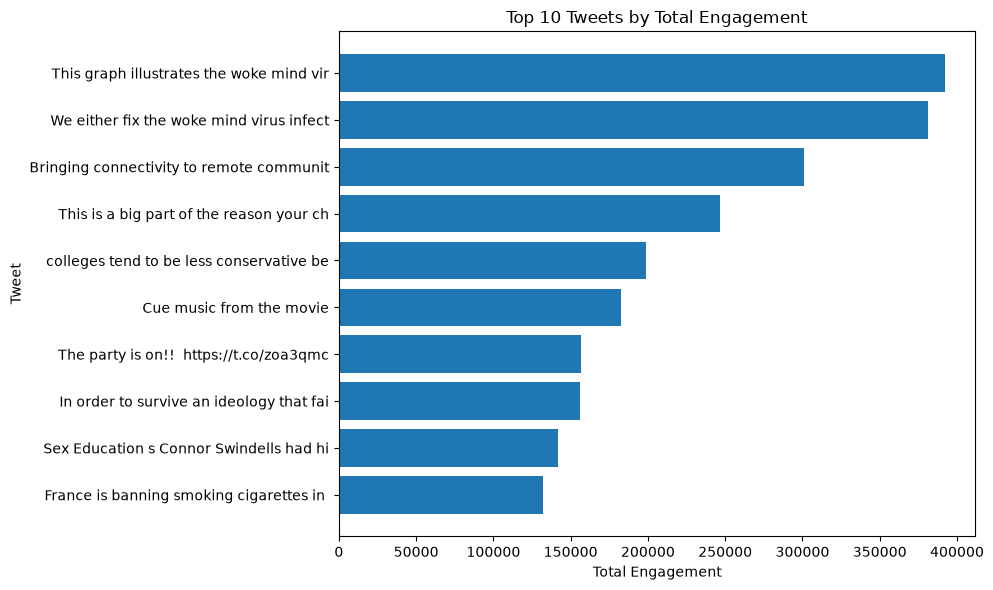

In [23]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_10["full_text"].str[:40],
    top_10["total_engagement"]
)

plt.xlabel("Total Engagement")
plt.ylabel("Tweet")
plt.title("Top 10 Tweets by Total Engagement")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

##7. Category Analysis

In [24]:
category_engagement = (
    df.groupby("category")["total_engagement"]
      .agg(["count", "sum", "mean"])
      .sort_values("sum", ascending=False)
)

category_engagement

,count,sum,mean
category,,,
Education,317,3827473,12074.047319
Sports,194,1659504,8554.144330
Health,146,511746,3505.109589
Music_Movie,287,435759,1518.324042
AI_Technology,295,241353,818.145763
Finance,110,37518,341.072727


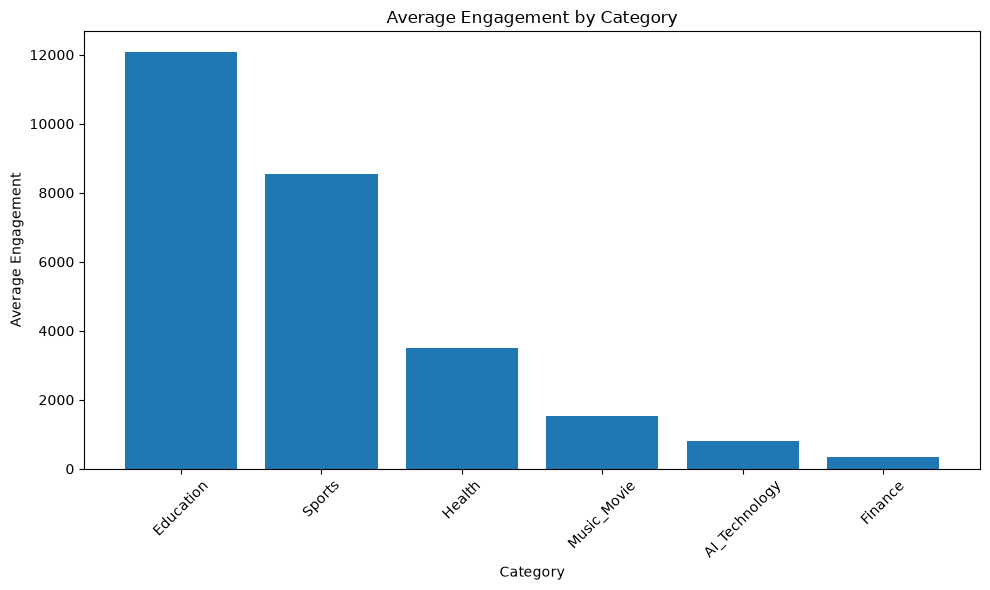

In [25]:
plt.figure(figsize=(10, 6))

plt.bar(
    category_engagement.index.astype(str),
    category_engagement["mean"]
)

plt.xlabel("Category")
plt.ylabel("Average Engagement")
plt.title("Average Engagement by Category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##8. Time Analysis

In [26]:
tweets_by_year = df.groupby("year").size()

tweets_by_year

year
2016       6
2017       9
2018       5
2019       4
2020       6
2021      11
2022      10
2023      18
2024      54
2025    1226
dtype: int64

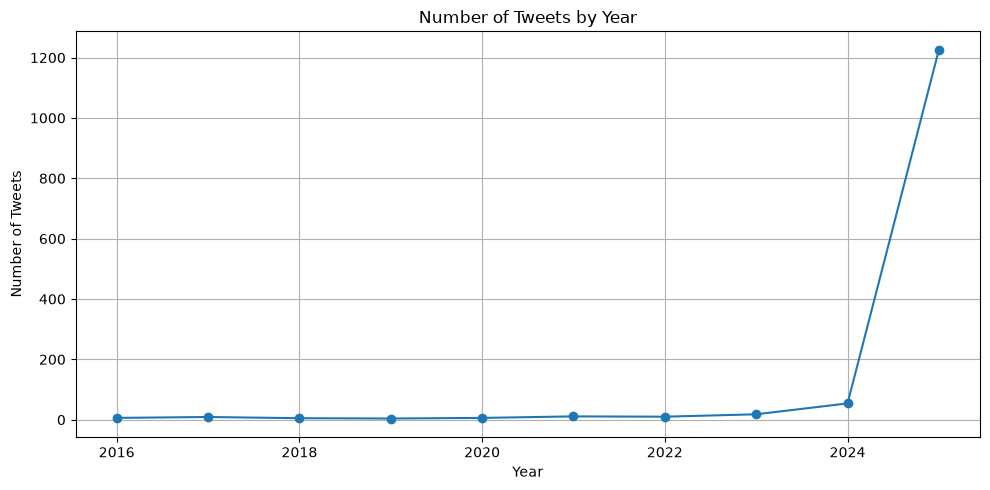

In [27]:
plt.figure(figsize=(10, 5))

plt.plot(
    tweets_by_year.index,
    tweets_by_year.values,
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Number of Tweets")
plt.title("Number of Tweets by Year")
plt.grid(True)
plt.tight_layout()
plt.show()

##9. Key insights

- Identified the tweets with the highest total engagement.
- Compared engagement levels across tweet categories.
- Analyzed Twitter activity across different years.
- Created visualizations to support engagement and content analysis.

##10. Conclusion



This analysis explored Twitter engagement, content categories, and activity over time. The results provide a foundation for further analysis using SQL and Power BI.